# AC Power -- Testing Ground

In [1]:
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date, datetime, timedelta
from itertools import product
from copy import deepcopy
from gen_variable_standard_static import find_aggregate_variable_names_gen_mod, \
find_all_variable_names_gen_mod, check_variable_data_exists, sources_checker, \
check_variable_data_exists_single_system, metrics_search_for_fragment_df, \
metrics_search_for_two_fragments_df
from tqdm import tqdm

In [2]:
systems_cleaned = pd.read_csv('../../../data/core/systems_cleaned.csv')
systems_cleaned.columns

Index(['system_id', 'system_public_name', 'site_location',
       'timezone_or_utc_offset', 'latitude', 'longitude', 'elevation_m',
       'dc_capacity_kW', 'kg_climate', 'pvcz_composite', 'pvcz_t_rack',
       'pvcz_t_roof', 'pvcz_humidity', 'pvcz_wind', 'tracking', 'type',
       'azimuth', 'tilt', 'first_timestamp', 'last_timestamp', 'years',
       'number_records', 'dataset_size_mb', 'available_sensor_channels',
       'qa_status', 'qa_issue', 'first_year', 'is_prize_data',
       'is_lake_parquet_data', 'is_lake_csv_data', 'has_irradiance_data',
       'has_ambient_temperature_data', 'has_temperature_data',
       'has_power_data', 'has_current_data', 'has_voltage_data', 'has_ac_data',
       'has_dc_data', 'module_type', 'simplified_type', 'system_source',
       'sample_year', 'num_days_actual_records'],
      dtype='str')

In [3]:
metrics_dir = Path("../../../data/raw/parquet-metrics/")
metrics_pq = pq.ParquetDataset(metrics_dir)
metrics_df = metrics_pq.read().to_pandas()
metrics_id_set = set(metrics_df.system_id)

## Potential-outlier investigation

In [4]:
def simple_system_reader(
        system_id: int,
        metrics_col,
        start_date = None,
        end_date = None
):
    path_system = Path(f'../../../../data_ds_project/systems/parquet/{system_id}/')
    filters_list = []
    if metrics_col is not None:
        filters_list.append(('metric_id', 'in', metrics_col))
    if start_date is not None:
        filters_list.append(('measured_on', '>=', start_date))
    if end_date is not None:
        filters_list.append(('measured_on', '<', end_date))
    if len(filters_list) > 0:
        pq_system = pq.ParquetDataset(
            path_system,
            filters=filters_list
        )
    else:
        pq_system = pq.ParquetDataset(
            path_system
        )
    df_system = pq_system.read().to_pandas()
    return df_system.drop_duplicates()


In [5]:
def simple_system_grapher(
    system_id: int,
    system_data: pd.DataFrame,
    var_name: str,
    unit: str,
    start_datetime,
    end_datetime   
):
    if unit == 'W':
        system_data_pos = system_data[system_data['value'] > 20]
    elif unit == 'kW':
        system_data_pos = system_data[system_data['value'] > 0.02]
    else:
        raise ValueError('Invalid unit selection -- only "W" and "kW".')
    system_data_loc = system_data_pos[
        (system_data_pos['measured_on'] >= start_datetime)
        & (system_data_pos['measured_on'] < end_datetime)
    ]
    max_loc = system_data_loc['value'].max()
    ax = sns.scatterplot(
        data = system_data_loc,
        x = 'measured_on',
        y = 'value'
    )
    ax.set(ylabel=var_name, title = f'System {system_id}, local max val {max_loc:.2f}')
    ax.tick_params('x', labelrotation = 30)
    plt.show()

In [6]:
def multiple_data_system_grapher(
    system_id: int,
    system_data: pd.DataFrame,
    unit: str,
    start_datetime,
    end_datetime   
):
    if unit == 'W':
        system_data_pos = system_data[system_data['value'] > 20]
    elif unit == 'kW':
        system_data_pos = system_data[system_data['value'] > 0.02]
    else:
        raise ValueError('Invalid unit selection -- only "W" and "kW".')
    system_data_loc = system_data_pos[
        (system_data_pos['measured_on'] >= start_datetime)
        & (system_data_pos['measured_on'] < end_datetime)
    ]
    max_loc = system_data_loc['value'].max()
    ax = sns.scatterplot(
        data = system_data_loc,
        x = 'measured_on',
        y = 'value',
        hue = 'metric_id'
    )
    ax.set(title = f'System {system_id}, local max val {max_loc:.2f}')
    ax.tick_params('x', labelrotation = 30)
    plt.show()

### System 4

In [60]:
systems_cleaned[systems_cleaned['system_id']==4]

,system_id,system_public_name,site_location,timezone_or_utc_offset,latitude,longitude,elevation_m,dc_capacity_kW,kg_climate,pvcz_composite,...,has_power_data,has_current_data,has_voltage_data,has_ac_data,has_dc_data,module_type,simplified_type,system_source,num_days_actual_records,sample_year
2,4,NREL x-Si -1,"Golden, CO",7,39.7406,-105.1774,1795.3,1.0,BSk,12,...,True,True,True,True,True,mono-Si,monocrystalline_Si,PVDAQ General,5063,2008


In [43]:
system_id = 4
relevant_rows_metrics = metrics_df[metrics_df['system_id'] == system_id]
metrics_search_for_two_fragments_df(relevant_rows_metrics, 'pow', 'ac', 'and')

,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
1712,4,315,ac_power,AC power,W,W,1.0,0.0,,avg,NaN,NaN,,ac_power__315
1714,4,327,power_factor,AC other,na,na,1.0,0.0,,avg,NaN,NaN,,power_factor__327


In [44]:
df_4 = simple_system_reader(4, [315,], datetime(2009, 1, 1), datetime(2016, 1, 1))

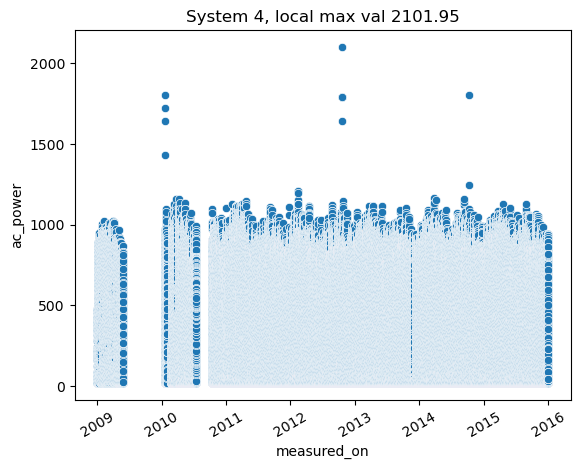

In [45]:
simple_system_grapher(4, df_4, 'ac_power', 'W', datetime(2009, 1, 1), datetime(2016, 1, 1))

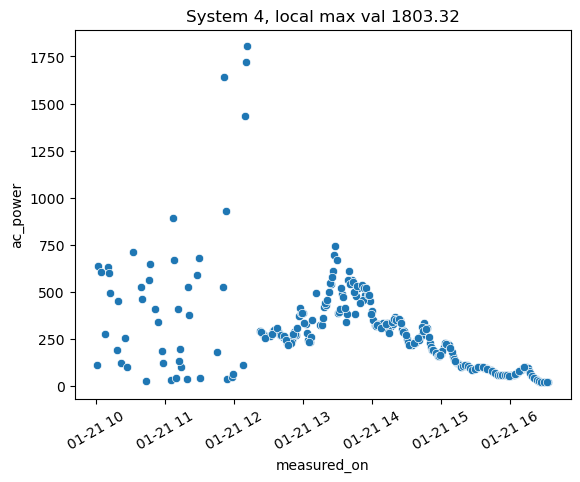

In [59]:
simple_system_grapher(4, df_4, 'ac_power', 'W', datetime(2010, 1, 21), datetime(2010, 1, 22))

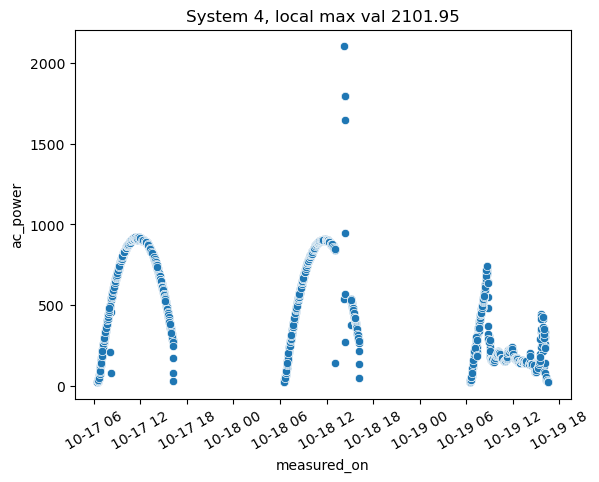

In [54]:
simple_system_grapher(4, df_4, 'ac_power', 'W', datetime(2012, 10, 17), datetime(2012, 10, 20))

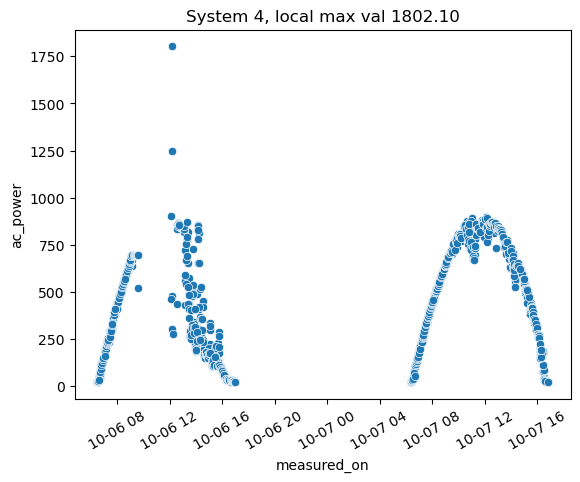

In [58]:
simple_system_grapher(4, df_4, 'ac_power', 'W', datetime(2014, 10, 6), datetime(2014, 10, 8))

### System 10

In [63]:
system_id = 10
relevant_rows_metrics = metrics_df[metrics_df['system_id'] == system_id]
metrics_search_for_two_fragments_df(relevant_rows_metrics, 'pow', 'ac', 'and')

,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
1,10,423,ac_power,AC power,W,W,1.0,0.0,,avg,NaN,NaN,,ac_power__423


In [65]:
systems_cleaned[systems_cleaned['system_id']==10]

,system_id,system_public_name,site_location,timezone_or_utc_offset,latitude,longitude,elevation_m,dc_capacity_kW,kg_climate,pvcz_composite,...,has_power_data,has_current_data,has_voltage_data,has_ac_data,has_dc_data,module_type,simplified_type,system_source,num_days_actual_records,sample_year
3,10,NREL CIS -1,"Golden, CO",7,39.7404,-105.1774,1792.8,1.12,BSk,12,...,True,True,True,True,True,cis family thin-film,thin_film,PVDAQ General,5893,2007


In [64]:
df_10 = simple_system_reader(10, [423,], datetime(2007, 1, 1), datetime(2020, 1, 1))

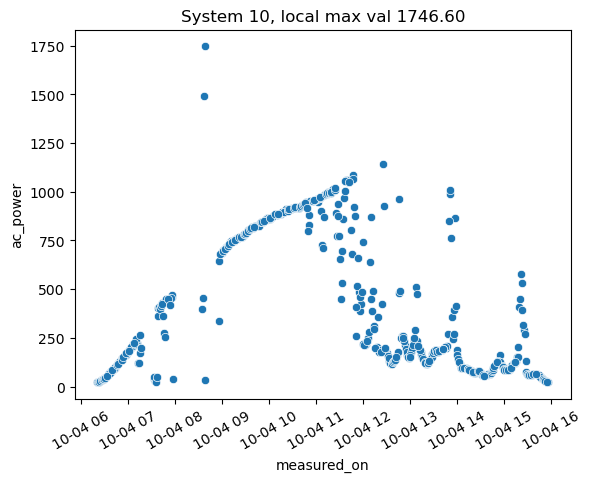

In [69]:
simple_system_grapher(10, df_10, 'ac_power', 'W', datetime(2011, 10, 4), datetime(2011, 10, 5))

### System 36

In [8]:
system_id = 36
relevant_rows_metrics = metrics_df[metrics_df['system_id'] == system_id]
metrics_search_for_two_fragments_df(relevant_rows_metrics, 'pow', 'ac', 'and')

,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
1350,36,629,ac_power,AC power,W,W,1.0,0.0,,avg,NaN,NaN,,ac_power__629


In [61]:
systems_cleaned[systems_cleaned['system_id']==36]

,system_id,system_public_name,site_location,timezone_or_utc_offset,latitude,longitude,elevation_m,dc_capacity_kW,kg_climate,pvcz_composite,...,has_power_data,has_current_data,has_voltage_data,has_ac_data,has_dc_data,module_type,simplified_type,system_source,num_days_actual_records,sample_year
7,36,NREL low-X x-Si -1,"Golden, CO",7,39.704,-105.1773,1794.7,2.21,BSk,12,...,True,True,True,True,True,Unknown,unknown,PVDAQ General,2516,2013


In [10]:
df_36 = simple_system_reader(36, [629,], datetime(2012, 1, 1), datetime(2013, 1, 1))

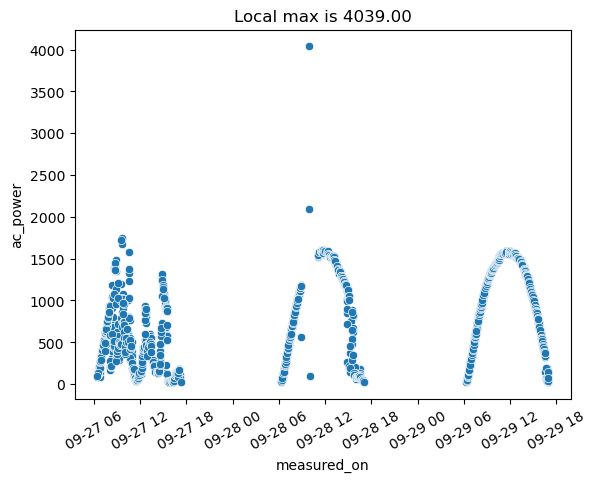

In [ ]:
df_36_pos = df_36[df_36['value'] > 20]
df_36_loc = df_36_pos[
    (df_36_pos['measured_on'] >= datetime(2012, 9, 27))
    & (df_36_pos['measured_on'] < datetime(2012, 9, 30))
]
df_36_loc_max = df_36_loc['value'].max()
ax = sns.scatterplot(
    data = df_36_loc,
    x = 'measured_on',
    y = 'value'
)
ax.set(ylabel = 'ac_power', title = f'Local max is {df_36_loc_max:.2f}')
ax.tick_params('x', labelrotation = 30)
plt.show()

### System 1208

Unusual inverter data in 2012

In [76]:
system_id = 1208
relevant_rows_metrics = metrics_df[metrics_df['system_id'] == system_id]
metrics_search_for_two_fragments_df(relevant_rows_metrics, 'pow', 'ac', 'and')

,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
227,1208,1133,ac_power_metered_1_2,AC power,W,W,1.0,0.0,ac_meter_1_power_kW+ac_meter_2_power_kW,avg,NaN,NaN,,ac_power_metered_1_2__1133
230,1208,1016,ac_power_metered_kW,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,ac_power_metered_kw__1016
231,1208,1017,ac_meter_1_power_kW,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,ac_meter_1_power_kw__1017
232,1208,1018,ac_meter_2_power_kW,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,ac_meter_2_power_kw__1018
233,1208,1019,inv1_ac_power_kW,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,inv1_ac_power_kw__1019
234,1208,1023,inv2_ac_power_kW,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,inv2_ac_power_kw__1023


In [77]:
df_1208 = simple_system_reader(1208, [1019, 1023,], datetime(2012, 1, 1), datetime(2013, 1, 1))

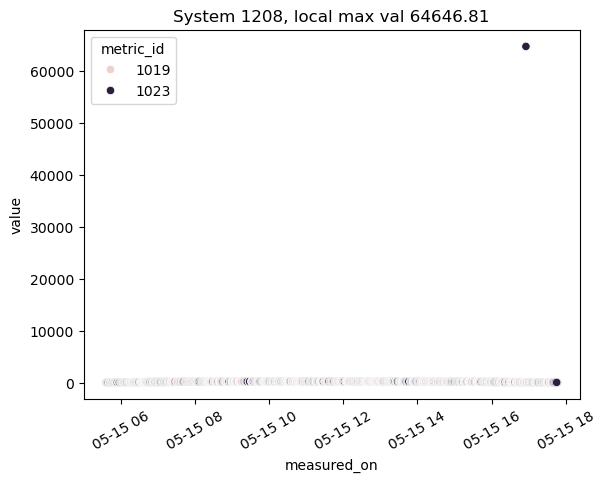

In [85]:
multiple_data_system_grapher(
    1208,
    df_1208,
    'W',
    datetime(2012, 5, 15),
    datetime(2012, 5, 16)
)

Bad data on May 15, 2012

### System 1289

In [15]:
system_id = 1289
relevant_rows_metrics = metrics_df[metrics_df['system_id'] == system_id]
metrics_search_for_two_fragments_df(relevant_rows_metrics, 'pow', 'ac', 'and')

,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
542,1289,1060,ac_power,AC power,W,W,1.0,0.0,,avg,NaN,NaN,,ac_power__1060
556,1289,1074,power_factor,AC other,-,-,1.0,0.0,,NaN,NaN,NaN,,power_factor__1074


In [62]:
systems_cleaned[systems_cleaned.system_id == 1289]

,system_id,system_public_name,site_location,timezone_or_utc_offset,latitude,longitude,elevation_m,dc_capacity_kW,kg_climate,pvcz_composite,...,has_power_data,has_current_data,has_voltage_data,has_ac_data,has_dc_data,module_type,simplified_type,system_source,num_days_actual_records,sample_year
70,1289,NREL CIGS-12,Golden CO,7,39.7405,-105.1774,1793.7,1.82,Dfb,12,...,True,True,True,True,True,cylindrical cigs,thin_film,PVDAQ General,2639,2013


In [16]:
df_1289 = simple_system_reader(1289, [1060,], datetime(2014, 1, 1), datetime(2015, 1, 1))

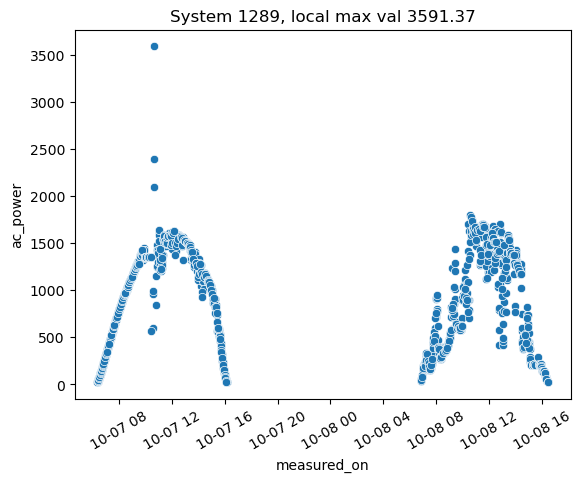

In [26]:
simple_system_grapher(1289, df_1289, 'ac_power', 'W', datetime(2014, 10, 7), datetime(2014, 10, 9))

### System 1321

Data blip in 2017

In [86]:
system_id = 1321
relevant_rows_metrics = metrics_df[metrics_df['system_id'] == system_id]
metrics_search_for_two_fragments_df(relevant_rows_metrics, 'pow', 'ac', 'and')

,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
829,1321,301,RTW,AC power,W,W,1.0,0.0,,avg,NaN,NaN,,rtw__301


In [87]:
df_1321 = simple_system_reader(1321, [301,], datetime(2016, 1, 1), datetime(2019, 1, 1))

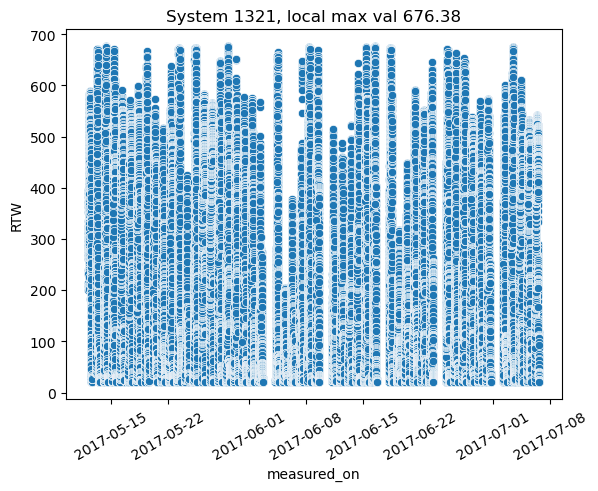

In [89]:
simple_system_grapher(1321, df_1321, 'RTW', 'W', datetime(2016, 1, 1), datetime(2018, 12, 31, 12))

Confirmed -- reporting in 2017 for about 2 months, then demolished

### System 1332
Data issues near 2021

In [90]:
system_id = 1332
relevant_rows_metrics = metrics_df[metrics_df['system_id'] == system_id]
metrics_search_for_two_fragments_df(relevant_rows_metrics, 'pow', 'ac', 'and')

,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
864,1332,2641,meter3_ac_power,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,meter3_ac_power__2641
865,1332,2640,meter2_ac_power,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,meter2_ac_power__2640
869,1332,2642,inv1_ac_power,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,inv1_ac_power__2642
870,1332,2646,inv2_ac_power,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,inv2_ac_power__2646
871,1332,2650,inv3_ac_power,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,inv3_ac_power__2650
872,1332,2639,meter1_ac_power,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,meter1_ac_power__2639
873,1332,2638,metered_ac_power,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,metered_ac_power__2638
874,1332,2654,inv_total_ac_power,AC power,W,W,1.0,0.0,inv1_ac_power+inv2_ac_power+inv3_ac_power,avg,NaN,NaN,,inv_total_ac_power__2654


In [92]:
df_1332 = simple_system_reader(1332, [2654,], datetime(2020, 12, 1), datetime(2022, 2, 1))

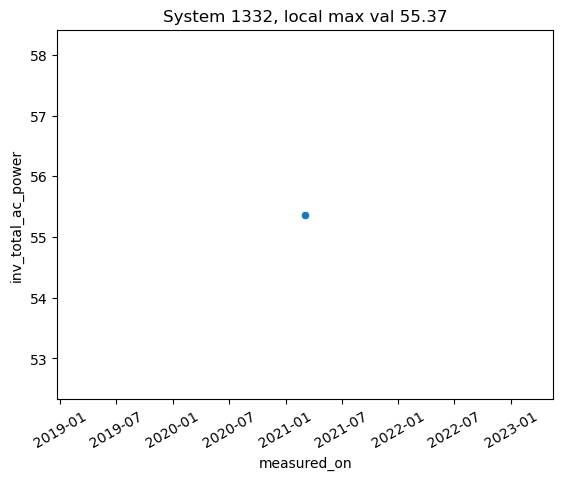

In [93]:
simple_system_grapher(1332, df_1332, 'inv_total_ac_power', 'W', datetime(2020, 12, 1), datetime(2022, 2, 1))

In [95]:
df_1332

,measured_on,utc_measured_on,metric_id,value
0,2021-03-05 07:22:00,2021-03-05 14:22:00,2654,0.0000
1,2021-03-05 07:22:15,2021-03-05 14:22:15,2654,55.3714
2,2021-07-22 06:55:45,2021-07-22 13:55:45,2654,-0.9000
3,2021-09-09 08:54:15,2021-09-09 15:54:15,2654,0.0000
4,2021-12-17 05:57:30,2021-12-17 12:57:30,2654,-0.2308
5,2021-12-17 05:57:15,2021-12-17 12:57:15,2654,0.0000


Only 1 nontrivial data point in all of 2021!  Can ignore!

### System 1422

In [27]:
system_id = 1422
relevant_rows_metrics = metrics_df[metrics_df['system_id'] == system_id]
metrics_search_for_two_fragments_df(relevant_rows_metrics, 'pow', 'ac', 'and')

,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
1174,1422,4830,inv1_ac_power,AC power,W,W,1.0,0.0,,avg,NaN,NaN,,inv1_ac_power__4830
1175,1422,4836,inv2_ac_power,AC power,W,W,1.0,0.0,,avg,NaN,NaN,,inv2_ac_power__4836
1176,1422,5375,ac_power,AC power,W,W,1.0,0.0,,avg,NaN,NaN,,ac_power__5375


In [34]:
systems_cleaned[systems_cleaned['system_id'] == 1422]

,system_id,system_public_name,site_location,timezone_or_utc_offset,latitude,longitude,elevation_m,dc_capacity_kW,kg_climate,pvcz_composite,...,has_power_data,has_current_data,has_voltage_data,has_ac_data,has_dc_data,module_type,simplified_type,system_source,num_days_actual_records,sample_year
147,1422,[1422] RTC-VT-Baseline,"Burlington, VT",America/New_York,44.4665,-73.1014,109.0,6.0,Dfb,32,...,True,True,True,True,True,mono-Si,monocrystalline_Si,PVDAQ General,1111,2015


Recall that 5375 is fake -- no data.  Inverters by themselves.

In [73]:
df_1422 = simple_system_reader(1422, [4830, 4836,], datetime(2016, 1, 1), datetime(2018, 1, 1))

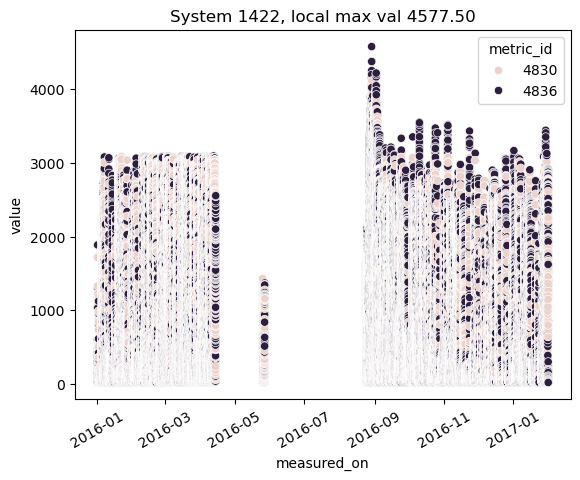

In [75]:
multiple_data_system_grapher(
    1422,
    df_1422,
    'W',
    datetime(2016, 1, 1),
    datetime(2017, 2, 1)
)

### System 1431

In [35]:
system_id = 1431
relevant_rows_metrics = metrics_df[metrics_df['system_id'] == system_id]
metrics_search_for_two_fragments_df(relevant_rows_metrics, 'pow', 'ac', 'and')

,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
1263,1431,5086,ac_power,AC power,W,W,1000.0,0.0,kWh_gross*4,avg,NaN,NaN,,ac_power__5086


In [36]:
systems_cleaned[systems_cleaned['system_id'] == 1431]

,system_id,system_public_name,site_location,timezone_or_utc_offset,latitude,longitude,elevation_m,dc_capacity_kW,kg_climate,pvcz_composite,...,has_power_data,has_current_data,has_voltage_data,has_ac_data,has_dc_data,module_type,simplified_type,system_source,num_days_actual_records,sample_year
151,1431,[1431] NREL Windsite PV 1-axis,"Boulder, CO",America/Denver,39.9094,-105.2311,1850.0,1082.85,Dfb,11,...,True,True,True,True,True,ribbon polycrystalline si,multicrystalline_Si,PVDAQ General,2957,2010


In [37]:
df_1431 = simple_system_reader(1431, [5086,], datetime(2016, 1, 1), datetime(2017, 1, 1))

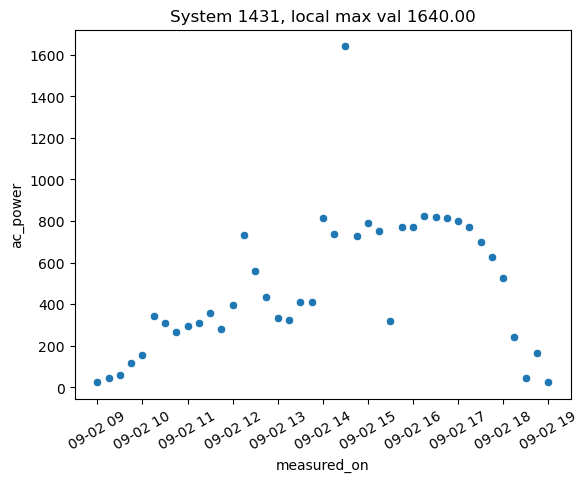

In [42]:
simple_system_grapher(1431, df_1431, 'ac_power', 'W', datetime(2016, 9, 2), datetime(2016, 9, 3))

## Other weird-data systems

### System 1208

Competing metered-data systems

In [96]:
system_id = 1208
relevant_rows_metrics = metrics_df[metrics_df['system_id'] == system_id]
metrics_search_for_two_fragments_df(relevant_rows_metrics, 'pow', 'ac', 'and')

,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
227,1208,1133,ac_power_metered_1_2,AC power,W,W,1.0,0.0,ac_meter_1_power_kW+ac_meter_2_power_kW,avg,NaN,NaN,,ac_power_metered_1_2__1133
230,1208,1016,ac_power_metered_kW,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,ac_power_metered_kw__1016
231,1208,1017,ac_meter_1_power_kW,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,ac_meter_1_power_kw__1017
232,1208,1018,ac_meter_2_power_kW,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,ac_meter_2_power_kw__1018
233,1208,1019,inv1_ac_power_kW,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,inv1_ac_power_kw__1019
234,1208,1023,inv2_ac_power_kW,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,inv2_ac_power_kw__1023


In [104]:
systems_cleaned[systems_cleaned['system_id'] == 1208]

,system_id,system_public_name,site_location,timezone_or_utc_offset,latitude,longitude,elevation_m,dc_capacity_kW,kg_climate,pvcz_composite,...,has_power_data,has_current_data,has_voltage_data,has_ac_data,has_dc_data,module_type,simplified_type,system_source,num_days_actual_records,sample_year
17,1208,NREL Visitors Parking,"Golden, CO",7,39.7407,-105.1694,1780.0,2.713508,BSk,12,...,True,True,True,True,True,mono-Si,monocrystalline_Si,PVDAQ General,3591,2012


In [97]:
df_1208 = simple_system_reader(1208, [1016, 1133], datetime(2011, 1, 1), datetime(2023, 1, 1))

In [98]:
df_1208_early = df_1208[df_1208['measured_on'] < datetime(2018, 8, 4)]
df_1208_late = df_1208[df_1208['measured_on'] >= datetime(2018, 8, 5)]

In [100]:
# correct units to W throughout
df_1208_early['value'] = df_1208_early.apply(
    lambda row: row['value'] * 1000 if row['metric_id'] == 1016 else row['value'],
    axis=1
)
df_1208_late['value'] = df_1208_late.apply(
    lambda row: row['value'] * 1000 if row['metric_id'] == 1133 else row['value'],
    axis=1
)

c:\Users\ch83b\anaconda3\envs\erdos_ds_environment\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


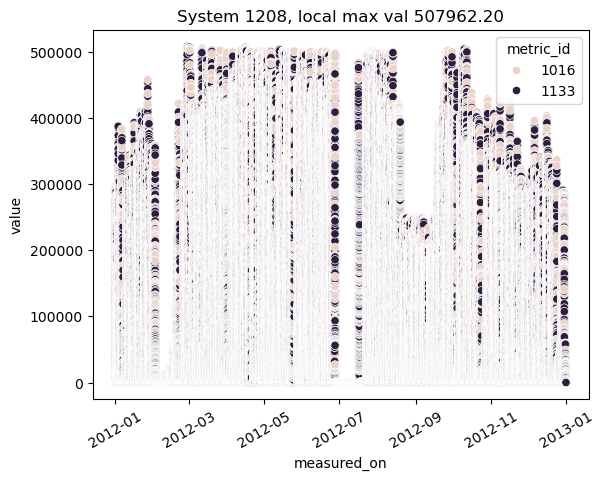

In [102]:
multiple_data_system_grapher(
    1208,
    df_1208_early,
    'W',
    datetime(2012, 1, 1),
    datetime(2013, 1, 1)
)

'Before', either version is good.

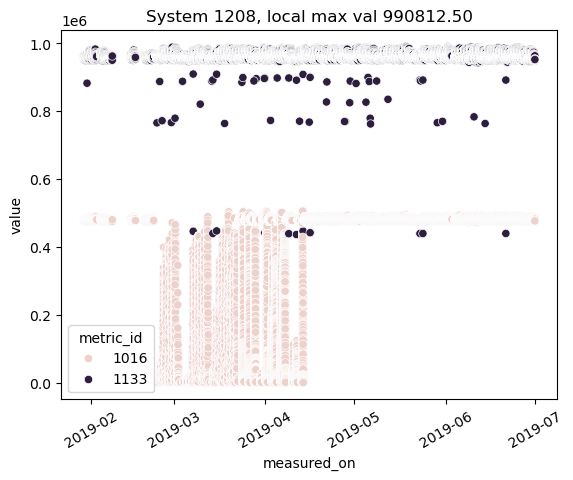

In [103]:
multiple_data_system_grapher(
    1208,
    df_1208_late,
    'W',
    datetime(2019, 1, 1),
    datetime(2019, 7, 1)
)

'After', `ac_power_metered_1_2` is doubled that of `ac_power_metered_kW`!  For standardization, must go with `ac_power_metered_kW`!

## System 1332

In [7]:
system_id = 1332
relevant_rows_metrics = metrics_df[metrics_df['system_id'] == system_id]
metrics_search_for_two_fragments_df(relevant_rows_metrics, 'pow', 'ac', 'and')

,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
864,1332,2641,meter3_ac_power,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,meter3_ac_power__2641
865,1332,2640,meter2_ac_power,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,meter2_ac_power__2640
869,1332,2642,inv1_ac_power,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,inv1_ac_power__2642
870,1332,2646,inv2_ac_power,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,inv2_ac_power__2646
871,1332,2650,inv3_ac_power,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,inv3_ac_power__2650
872,1332,2639,meter1_ac_power,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,meter1_ac_power__2639
873,1332,2638,metered_ac_power,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,metered_ac_power__2638
874,1332,2654,inv_total_ac_power,AC power,W,W,1.0,0.0,inv1_ac_power+inv2_ac_power+inv3_ac_power,avg,NaN,NaN,,inv_total_ac_power__2654


In [8]:
df_1332 = simple_system_reader(1332, [2654,], datetime(2016, 1, 1), datetime(2022, 1, 1))

In [9]:
df_1332_early = df_1332[df_1332['measured_on'] < datetime(2018, 8, 4)]
df_1332_late = df_1332[df_1332['measured_on'] >= datetime(2018, 8, 5)]

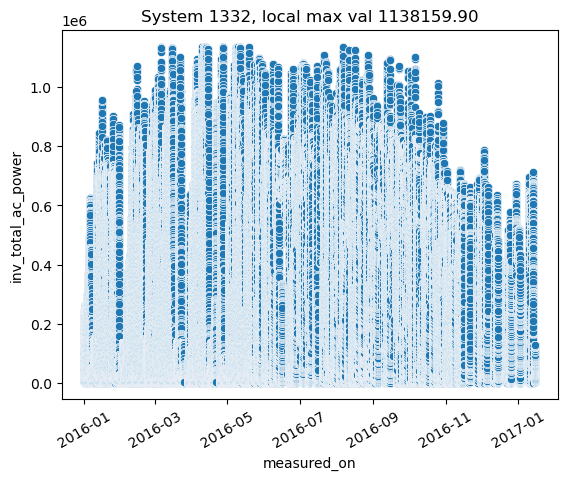

In [12]:
simple_system_grapher(
    1332,
    df_1332_early,
    'inv_total_ac_power',
    'W',
    datetime(2016, 1, 1),
    datetime(2018, 1, 1)
)

In [16]:
df_1332_late.shape

(118209, 4)

In [17]:
df_1332_late[df_1332_late['value'] > 0]

,measured_on,utc_measured_on,metric_id,value
1501084,2020-11-14 08:53:15,2020-11-14 15:53:15,2654,9.1500
1501087,2021-03-05 07:22:15,2021-03-05 14:22:15,2654,55.3714


Only 2 values of 2654 past 2018 with positive values!  Not reliable.